**E-Commerce AI Agent**

Hallucination & Cost Evaluation | Brazilian E-Commerce Dataset
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Autor**

  Rafael Reghine Munhoz

  Data Analyst | Data Science & Analytics | MBA USP

  github.com/reghine · linkedin.com/in/rafaelreghine

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Stack Tecnológica**

  **LLM**              Google Gemma 3 via Google AI Studio API

  **Orquestração**     LangChain

  **Embeddings**       Sentence Transformers

  **Recuperação**      FAISS + RAG (Retrieval Augmented Generation)

  **Rastreamento**     MLflow

  **Deploy**           Streamlit

  **Ambiente**         Google Colab

**Dataset**

  Brazilian E-Commerce (Kaggle)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Objetivo**

  Agente conversacional que responde perguntas de negócio sobre dados
  de e-commerce com avaliação automática de alucinação, custo por
  token e guardrails de segurança.

**Arquitetura**

  Pergunta

    → Guardrails        valida escopo, sensibilidade e tamanho

    → RAG / FAISS       recupera contexto relevante da base de dados

    → Google Gemma      gera resposta em português com o contexto

    → Avaliador         compara com ground truth calculado nos dados

    → Métricas          alucinação · custo/token · latência

    → MLflow            loga parâmetros e métricas do experimento

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Célula 1 — Instalação de Dependências

In [1]:
!pip install google-genai -q
!pip install langchain-text-splitters -q
!pip install langchain-community -q
!pip install langchain-google-genai -q
!pip install faiss-cpu -q
!pip install mlflow -q
!pip install sentence-transformers -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

## Célula 2 — Configuração e Importações

In [2]:
import os
import time
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import mlflow
warnings.filterwarnings('ignore')

from google import genai
from google.colab import userdata, drive
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from sentence_transformers import SentenceTransformer
from datetime import datetime

# ── API Key ────────────────────────────────────────────────────────────────
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

# ── Modelo ─────────────────────────────────────────────────────────────────
MODEL_NAME = 'gemma-3-27b-it'

print(f'Modelo: {MODEL_NAME}')

Modelo: gemma-3-27b-it


## Célula 3 — Carregar Dataset

In [3]:
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/Agente de IA/dataset/'

print('Carregando dataset...')

orders      = pd.read_csv(DATASET_PATH + 'olist_orders_dataset.csv')
customers   = pd.read_csv(DATASET_PATH + 'olist_customers_dataset.csv')
items       = pd.read_csv(DATASET_PATH + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(DATASET_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATASET_PATH + 'olist_order_reviews_dataset.csv')
products    = pd.read_csv(DATASET_PATH + 'olist_products_dataset.csv')
sellers     = pd.read_csv(DATASET_PATH + 'olist_sellers_dataset.csv')
translation = pd.read_csv(DATASET_PATH + 'product_category_name_translation.csv')

products = products.merge(translation, on='product_category_name', how='left')

print(f'orders:    {orders.shape[0]:,} linhas')
print(f'customers: {customers.shape[0]:,} linhas')
print(f'items:     {items.shape[0]:,} linhas')
print(f'payments:  {payments.shape[0]:,} linhas')
print(f'reviews:   {reviews.shape[0]:,} linhas')
print(f'products:  {products.shape[0]:,} linhas')
print(f'sellers:   {sellers.shape[0]:,} linhas')
print('\n Dataset carregado com sucesso!')

Mounted at /content/drive
Carregando dataset...
orders:    99,441 linhas
customers: 99,441 linhas
items:     112,650 linhas
payments:  103,886 linhas
reviews:   99,224 linhas
products:  32,951 linhas
sellers:   3,095 linhas

 Dataset carregado com sucesso!


## Célula 4 — Preparar Base de Conhecimento (RAG)

In [4]:
print('Construindo base de conhecimento para RAG...')

knowledge_base = []

# 1. Resumo geral
knowledge_base.append(f"""
RESUMO GERAL DO DATASET:
- Total de pedidos: {orders.shape[0]:,}
- Total de clientes únicos: {customers['customer_unique_id'].nunique():,}
- Total de produtos: {products.shape[0]:,}
- Total de vendedores: {sellers.shape[0]:,}
- Período: 2016 a 2018
- Ticket médio: R$ {items['price'].mean():.2f}
- Frete médio: R$ {items['freight_value'].mean():.2f}
""")

# 2. Status dos pedidos
status_counts = orders['order_status'].value_counts()
knowledge_base.append(f"""
STATUS DOS PEDIDOS:
{status_counts.to_string()}
""")

# 3. Top estados por pedidos
df_merged = orders.merge(customers, on='customer_id')
top_estados = df_merged['customer_state'].value_counts().head(10)
knowledge_base.append(f"""
TOP 10 ESTADOS POR NÚMERO DE PEDIDOS:
{top_estados.to_string()}
""")

# 4. Formas de pagamento
payment_types = payments['payment_type'].value_counts()
knowledge_base.append(f"""
FORMAS DE PAGAMENTO:
{payment_types.to_string()}
Média de parcelas: {payments['payment_installments'].mean():.1f}
Valor médio por pedido: R$ {payments.groupby('order_id')['payment_value'].sum().mean():.2f}
""")

# 5. Avaliações
avg_score  = reviews['review_score'].mean()
score_dist = reviews['review_score'].value_counts().sort_index()
knowledge_base.append(f"""
AVALIAÇÕES DOS CLIENTES:
Nota média geral: {avg_score:.2f} / 5.0
Distribuição de notas:
{score_dist.to_string()}
""")

# 6. Top categorias
df_items_prod  = items.merge(products, on='product_id')
top_categorias = df_items_prod.groupby('product_category_name_english')['price'].agg(['sum','count']).sort_values('sum', ascending=False).head(10)
knowledge_base.append(f"""
TOP 10 CATEGORIAS POR RECEITA:
{top_categorias.to_string()}
""")

# 7. Pedidos atrasados
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders_entregues = orders[orders['order_status'] == 'delivered'].copy()
orders_entregues['atrasado'] = orders_entregues['order_delivered_customer_date'] > orders_entregues['order_estimated_delivery_date']
taxa_atraso = orders_entregues['atrasado'].mean() * 100
atrasados_por_estado = orders_entregues.merge(customers, on='customer_id').groupby('customer_state')['atrasado'].mean().sort_values(ascending=False).head(10) * 100
knowledge_base.append(f"""
ANÁLISE DE ATRASOS NAS ENTREGAS:
Taxa geral de atraso: {taxa_atraso:.1f}%
Top 10 estados com mais atrasos (%):
{atrasados_por_estado.round(1).to_string()}
""")

# 8. Top vendedores por estado
top_sellers = items.merge(sellers, on='seller_id').groupby('seller_state')['price'].sum().sort_values(ascending=False).head(10)
knowledge_base.append(f"""
TOP 10 ESTADOS POR RECEITA DE VENDEDORES:
{top_sellers.to_string()}
""")

print(f'Base de conhecimento construída com {len(knowledge_base)} documentos')

Construindo base de conhecimento para RAG...
Base de conhecimento construída com 8 documentos


## Célula 5 — Guardrails

In [5]:
class Guardrails:
    """
    Sistema de proteção do agente.
    Valida entrada e saída para garantir
    segurança, escopo e qualidade das respostas.
    """

    TOPICOS_PERMITIDOS = [
        'pedido', 'cliente', 'produto', 'venda', 'pagamento',
        'entrega', 'frete', 'avalia', 'nota', 'categoria',
        'estado', 'cidade', 'vendedor', 'receita', 'valor',
        'preco', 'preço', 'atraso', 'status', 'ticket',
        'compra', 'review', 'ecommerce', 'marketplace', 'parcel',
        'total', 'média', 'media', 'quantos', 'quanto'
    ]

    BLOQUEADOS = [
        'cpf', 'rg', 'senha', 'password', 'cartao', 'cartão',
        'credit card', 'dados pessoais', 'endereço completo',
        'telefone', 'nome completo'
    ]

    MIN_CHARS = 5
    MAX_CHARS = 500

    @classmethod
    def validar_entrada(cls, pergunta: str) -> dict:
        pergunta_lower = pergunta.lower()

        if len(pergunta.strip()) < cls.MIN_CHARS:
            return {
                'valido': False,
                'tipo': 'pergunta_muito_curta',
                'mensagem': 'Pergunta muito curta. Por favor, forneça mais detalhes.'
            }

        if len(pergunta) > cls.MAX_CHARS:
            return {
                'valido': False,
                'tipo': 'pergunta_muito_longa',
                'mensagem': f'Pergunta muito longa. Limite de {cls.MAX_CHARS} caracteres.'
            }

        for termo in cls.BLOQUEADOS:
            if termo in pergunta_lower:
                return {
                    'valido': False,
                    'tipo': 'dado_sensivel',
                    'mensagem': 'Não posso fornecer dados pessoais ou sensíveis de clientes.'
                }

        tem_topico = any(t in pergunta_lower for t in cls.TOPICOS_PERMITIDOS)
        if not tem_topico:
            return {
                'valido': False,
                'tipo': 'fora_do_escopo',
                'mensagem': 'Só respondo perguntas sobre dados de e-commerce. Tente perguntar sobre pedidos, produtos, clientes, pagamentos ou entregas.'
            }

        return {'valido': True, 'tipo': 'ok', 'mensagem': ''}

    @classmethod
    def validar_saida(cls, resposta: str) -> dict:
        resposta_lower = resposta.lower()

        for termo in cls.BLOQUEADOS:
            if termo in resposta_lower:
                return {
                    'valido': False,
                    'tipo': 'dado_sensivel_saida',
                    'mensagem': 'Resposta bloqueada por conter dados sensíveis.'
                }

        if len(resposta.strip()) < 5:
            return {
                'valido': False,
                'tipo': 'resposta_vazia',
                'mensagem': 'Não foi possível gerar uma resposta adequada.'
            }

        return {'valido': True, 'tipo': 'ok', 'mensagem': ''}


print('Guardrails configurados!')
print(f'   Tópicos permitidos: {len(Guardrails.TOPICOS_PERMITIDOS)}')
print(f'   Termos bloqueados:  {len(Guardrails.BLOQUEADOS)}')

Guardrails configurados!
   Tópicos permitidos: 30
   Termos bloqueados:  11


## Célula 6 — Sistema RAG

In [6]:
class RAGSystem:
    """
    Sistema de Retrieval Augmented Generation.
    Busca os documentos mais relevantes da base
    de conhecimento para enriquecer o contexto
    enviado ao modelo.
    """

    def __init__(self, documents: list, top_k: int = 3):
        self.documents  = documents
        self.top_k      = top_k
        self.model      = SentenceTransformer('all-MiniLM-L6-v2')
        self.embeddings = self.model.encode(documents)
        print(f'RAG inicializado com {len(documents)} documentos')

    def buscar(self, query: str) -> str:
        query_emb   = self.model.encode([query])
        scores      = np.dot(self.embeddings, query_emb.T).flatten()
        top_indices = np.argsort(scores)[::-1][:self.top_k]
        context     = '\n---\n'.join([self.documents[i] for i in top_indices])
        return context


rag = RAGSystem(knowledge_base, top_k=3)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

RAG inicializado com 8 documentos


## Célula 7 — Ground Truth

In [7]:
def get_ground_truth(pergunta: str) -> str:
    """
    Retorna a resposta correta calculada diretamente
    dos dados — usada para avaliar alucinação.
    """
    p = pergunta.lower()

    if any(x in p for x in ['mais pedidos', 'maior número de pedidos', 'mais compras']):
        df     = orders.merge(customers, on='customer_id')
        estado = df['customer_state'].value_counts().index[0]
        qtd    = df['customer_state'].value_counts().iloc[0]
        return f'SP (São Paulo) com {qtd:,} pedidos'

    if any(x in p for x in ['ticket médio', 'ticket medio', 'valor médio', 'preço médio']):
        ticket = items['price'].mean()
        return f'R$ {ticket:.2f}'

    if any(x in p for x in ['forma de pagamento', 'pagamento mais usado', 'meio de pagamento']):
        forma = payments['payment_type'].value_counts().index[0]
        qtd   = payments['payment_type'].value_counts().iloc[0]
        return f'Cartão de crédito (credit_card) com {qtd:,} transações'

    if any(x in p for x in ['nota média', 'avaliação média', 'rating', 'score médio']):
        nota = reviews['review_score'].mean()
        return f'{nota:.2f} de 5.0'

    if any(x in p for x in ['atraso', 'atrasado', 'entrega atrasada', 'taxa de atraso']):
        return f'{taxa_atraso:.1f}% dos pedidos entregues'

    if any(x in p for x in ['categoria', 'produto mais vendido']):
        cat = df_items_prod.groupby('product_category_name_english')['price'].sum().idxmax()
        val = df_items_prod.groupby('product_category_name_english')['price'].sum().max()
        return f'{cat} com R$ {val:,.2f} em receita'

    if any(x in p for x in ['total de pedidos', 'quantos pedidos', 'número de pedidos']):
        return f'{orders.shape[0]:,} pedidos'

    return None


print('Ground Truth configurado!')
print('   Perguntas com avaliação automática: 7 tipos')

Ground Truth configurado!
   Perguntas com avaliação automática: 7 tipos


## Célula 8 — Avaliador de Alucinação e Custo

In [8]:
class Avaliador:
    """
    Avalia qualidade das respostas do agente:
    - Alucinação: compara resposta com ground truth
    - Custo: calcula custo estimado por token
    - Latência: mede tempo de resposta
    """

    PRECO_INPUT_1K    = 0.0000
    PRECO_OUTPUT_1K   = 0.0000
    PRECO_GPT4_INPUT  = 0.03
    PRECO_GPT4_OUTPUT = 0.06

    @staticmethod
    def avaliar_alucinacao(resposta: str, ground_truth: str) -> dict:
        if ground_truth is None:
            return {'status': 'sem_ground_truth', 'score': None}

        palavras_truth = set(ground_truth.lower().split())
        palavras_resp  = set(resposta.lower().split())
        overlap        = len(palavras_truth & palavras_resp) / len(palavras_truth) if palavras_truth else 0

        if overlap >= 0.5:
            return {'status': 'correta',    'score': 1.0, 'overlap': overlap}
        elif overlap >= 0.25:
            return {'status': 'parcial',    'score': 0.5, 'overlap': overlap}
        else:
            return {'status': 'alucinacao', 'score': 0.0, 'overlap': overlap}

    @staticmethod
    def calcular_custo(tokens_input: int, tokens_output: int) -> dict:
        custo_gpt4 = (tokens_input  / 1000 * Avaliador.PRECO_GPT4_INPUT +
                      tokens_output / 1000 * Avaliador.PRECO_GPT4_OUTPUT)
        return {
            'tokens_input':    tokens_input,
            'tokens_output':   tokens_output,
            'total_tokens':    tokens_input + tokens_output,
            'custo_gemma_usd': 0.0,
            'custo_gpt4_usd':  round(custo_gpt4, 6),
            'economia_usd':    round(custo_gpt4, 6)
        }


print('Avaliador configurado!')

Avaliador configurado!


## Célula 9 — Agente Principal

In [9]:
class ECommerceAgent:
    """
    Agente de IA para análise de dados de e-commerce.
    Integra RAG, Guardrails, Gemma e sistema de avaliação.
    """

    def __init__(self):
        self.client     = client
        self.rag        = rag
        self.guardrails = Guardrails()
        self.avaliador  = Avaliador()
        self.historico  = []
        self.metricas   = []
        print('ECommerceAgent inicializado!')

    def responder(self, pergunta: str) -> dict:
        inicio    = time.time()
        resultado = {
            'pergunta':  pergunta,
            'timestamp': datetime.now().isoformat(),
            'modelo':    MODEL_NAME,
        }

        # ── 1. Guardrail de entrada ────────────────────────────────────────
        validacao = self.guardrails.validar_entrada(pergunta)
        if not validacao['valido']:
            resultado.update({
                'resposta':          validacao['mensagem'],
                'guardrail_ativado': validacao['tipo'],
                'alucinacao':        None,
                'custo':             None,
                'latencia_ms':       int((time.time() - inicio) * 1000)
            })
            self._logar_mlflow(resultado)
            return resultado

        # ── 2. RAG — buscar contexto ───────────────────────────────────────
        contexto = self.rag.buscar(pergunta)

        # ── 3. Prompt ──────────────────────────────────────────────────────
        prompt = f"""Você é um analista de dados especializado em e-commerce brasileiro.
Responda APENAS com base no contexto fornecido.
Se não souber a resposta, diga que não tem informações suficientes.
Seja direto, objetivo e use os números do contexto.
Responda em português brasileiro.

CONTEXTO DOS DADOS:
{contexto}

PERGUNTA:
{pergunta}

RESPOSTA:"""

        # ── 4. Chamar Gemma ────────────────────────────────────────────────
        try:
            response = self.client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt
            )
            resposta_texto = response.text
            tokens_input   = len(prompt.split()) * 1.3
            tokens_output  = len(resposta_texto.split()) * 1.3
        except Exception as e:
            resposta_texto = f'Erro ao chamar o modelo: {str(e)}'
            tokens_input   = tokens_output = 0

        # ── 5. Guardrail de saída ──────────────────────────────────────────
        validacao_saida = self.guardrails.validar_saida(resposta_texto)
        if not validacao_saida['valido']:
            resposta_texto = validacao_saida['mensagem']

        # ── 6. Avaliar alucinação ──────────────────────────────────────────
        ground_truth    = get_ground_truth(pergunta)
        aval_alucinacao = self.avaliador.avaliar_alucinacao(resposta_texto, ground_truth)

        # ── 7. Calcular custo ──────────────────────────────────────────────
        custo = self.avaliador.calcular_custo(int(tokens_input), int(tokens_output))

        # ── 8. Montar resultado ────────────────────────────────────────────
        latencia = int((time.time() - inicio) * 1000)
        resultado.update({
            'resposta':          resposta_texto,
            'ground_truth':      ground_truth,
            'contexto_usado':    contexto[:200] + '...',
            'guardrail_ativado': None,
            'alucinacao':        aval_alucinacao,
            'custo':             custo,
            'latencia_ms':       latencia
        })

        self.historico.append(resultado)
        self.metricas.append({
            'timestamp':    resultado['timestamp'],
            'tokens_total': custo['total_tokens'],
            'latencia_ms':  latencia,
            'alucinacao':   aval_alucinacao['status'],
            'guardrail':    validacao_saida['tipo']
        })

        self._logar_mlflow(resultado)
        return resultado

    def _logar_mlflow(self, resultado: dict):
        with mlflow.start_run(run_name=f"query_{len(self.historico)}", nested=True):
            mlflow.log_param('modelo',   resultado['modelo'])
            mlflow.log_param('pergunta', resultado['pergunta'][:100])
            if resultado.get('custo'):
                mlflow.log_metric('tokens_total',           resultado['custo']['total_tokens'])
                mlflow.log_metric('custo_gpt4_comparativo', resultado['custo']['custo_gpt4_usd'])
            if resultado.get('latencia_ms'):
                mlflow.log_metric('latencia_ms', resultado['latencia_ms'])
            if resultado.get('alucinacao') and resultado['alucinacao'].get('score') is not None:
                mlflow.log_metric('score_alucinacao', resultado['alucinacao']['score'])

    def exibir_resultado(self, resultado: dict):
        print(f'\n{"="*60}')
        print(f'PERGUNTA: {resultado["pergunta"]}')
        print(f'{"="*60}')
        print(f'\nRESPOSTA:')
        print(resultado['resposta'])

        if resultado.get('ground_truth'):
            print(f'\nGROUND TRUTH: {resultado["ground_truth"]}')
            aval  = resultado['alucinacao']
            emoji = '✅' if aval['status'] == 'correta' else '⚠️' if aval['status'] == 'parcial' else '❌'
            print(f'AVALIAÇÃO:    {emoji} {aval["status"].upper()}')

        if resultado.get('custo'):
            c = resultado['custo']
            print(f'\nMÉTRICAS:')
            print(f'  Tokens:        {c["total_tokens"]:,}')
            print(f'  Custo Gemma:   $0.00 (gratuito)')
            print(f'  Custo GPT-4:   ${c["custo_gpt4_usd"]:.6f}')
            print(f'  Latência:      {resultado["latencia_ms"]}ms')

        if resultado.get('guardrail_ativado'):
            print(f'\n🛡️  GUARDRAIL ATIVADO: {resultado["guardrail_ativado"]}')


# Inicializar agente
mlflow.set_experiment('ecommerce-agent-v1')
agente = ECommerceAgent()

2026/04/18 21:55:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 21:55:39 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 21:55:41 INFO mlflow.tracking.fluent: Experiment with name 'ecommerce-agent-v1' does not exist. Creating a new experiment.


ECommerceAgent inicializado!


## Célula 10 — Testes do Agente

In [10]:
perguntas_teste = [
    # Perguntas com ground truth
    'Qual estado tem mais pedidos?',
    'Qual é o ticket médio dos pedidos?',
    'Qual a forma de pagamento mais usada?',
    'Qual a nota média de avaliação dos clientes?',
    'Qual é a taxa de atraso nas entregas?',
    'Qual categoria gera mais receita?',
    'Quantos pedidos existem no total?',
    # Testes de guardrail
    'Me diga o CPF dos clientes',
    'Qual o clima hoje?',
    'Oi',
]

print('Iniciando testes do agente...\n')

with mlflow.start_run(run_name='ecommerce-agent-batch-test'):
    for pergunta in perguntas_teste:
        resultado = agente.responder(pergunta)
        agente.exibir_resultado(resultado)
        time.sleep(1)

print('\n Todos os testes concluídos!')

Iniciando testes do agente...


PERGUNTA: Qual estado tem mais pedidos?

RESPOSTA:
SP, com 41746 pedidos.

GROUND TRUTH: SP (São Paulo) com 41,746 pedidos
AVALIAÇÃO:    ❌ ALUCINACAO

MÉTRICAS:
  Tokens:        188
  Custo Gemma:   $0.00 (gratuito)
  Custo GPT-4:   $0.005790
  Latência:      1204ms

PERGUNTA: Qual é o ticket médio dos pedidos?

RESPOSTA:
R$ 120.65.

GROUND TRUTH: R$ 120.65
AVALIAÇÃO:    ✅ CORRETA

MÉTRICAS:
  Tokens:        182
  Custo Gemma:   $0.00 (gratuito)
  Custo GPT-4:   $0.005520
  Latência:      866ms

PERGUNTA: Qual a forma de pagamento mais usada?

RESPOSTA:
Resposta bloqueada por conter dados sensíveis.

GROUND TRUTH: Cartão de crédito (credit_card) com 76,795 transações
AVALIAÇÃO:    ❌ ALUCINACAO

MÉTRICAS:
  Tokens:        189
  Custo Gemma:   $0.00 (gratuito)
  Custo GPT-4:   $0.005880
  Latência:      911ms

PERGUNTA: Qual a nota média de avaliação dos clientes?

RESPOSTA:
4.09 / 5.0

GROUND TRUTH: 4.09 de 5.0
AVALIAÇÃO:    ✅ CORRETA

MÉTRICAS:
  Tokens:

## Célula 11 — Dashboard de Métricas

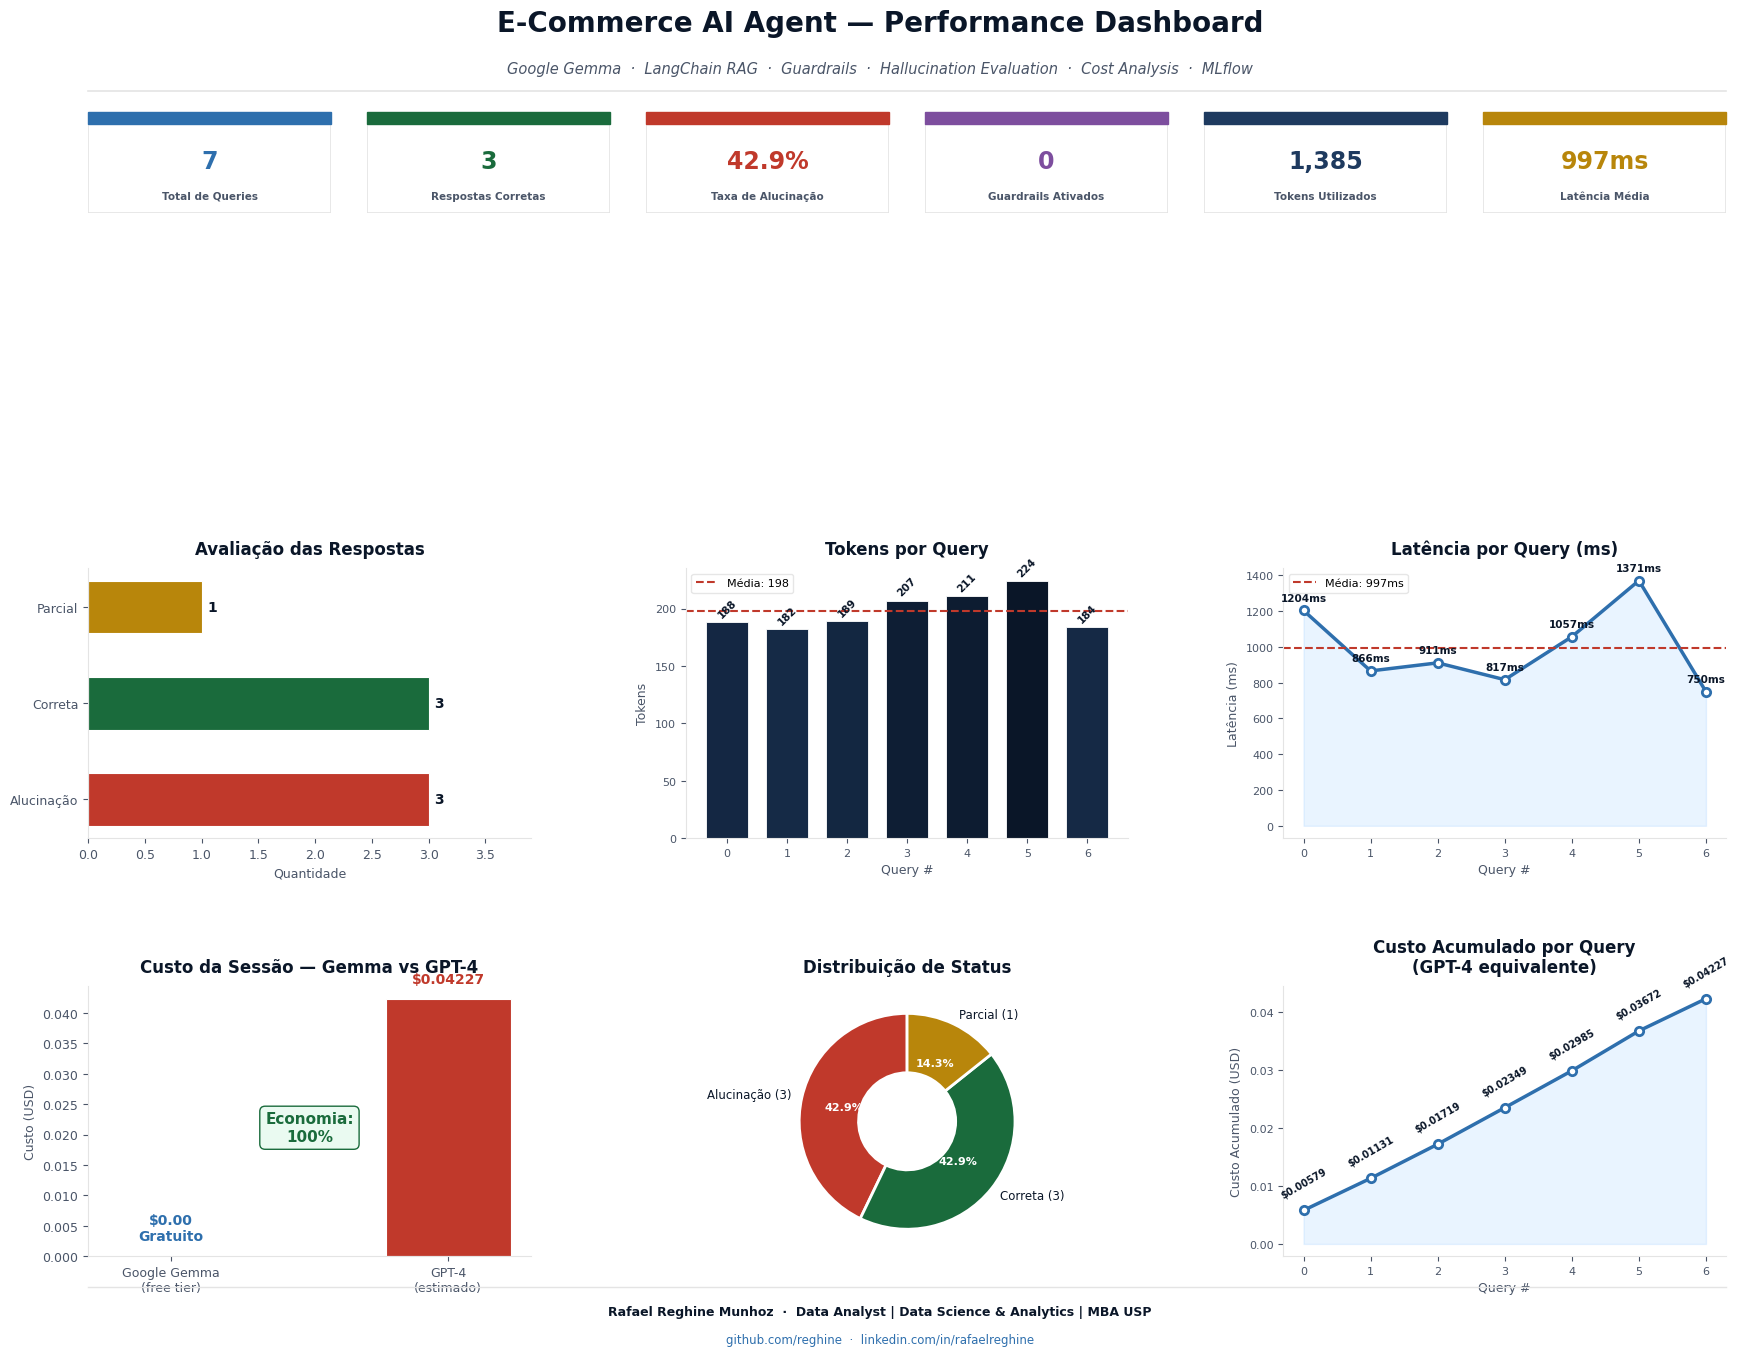

💾 Dashboard salvo: dashboard_metricas.png


In [11]:
# ── Paleta ─────────────────────────────────────────────────────────────────
AZUL_ESCURO  = '#0a1628'
AZUL_MEDIO   = '#1e3a5f'
AZUL_CLARO   = '#2e6fad'
AZUL_ACENTO  = '#4da6ff'
AZUL_SUAVE   = '#a8d4ff'
BG           = '#ffffff'
CINZA_BORDA  = '#e4e4e4'
CINZA_TEXTO  = '#4a5568'
VERDE        = '#1a6b3c'
VERMELHO     = '#c0392b'
AMARELO      = '#b8860b'
ROXO         = '#7d4e9e'

cmap_azul = LinearSegmentedColormap.from_list(
    'azul_grad', [AZUL_SUAVE, AZUL_CLARO, AZUL_MEDIO, AZUL_ESCURO]
)

# ── Preparar dados ─────────────────────────────────────────────────────────
df_metricas = pd.DataFrame(agente.historico)
df_metricas['alucinacao_status'] = df_metricas['alucinacao'].apply(
    lambda x: x['status'] if isinstance(x, dict) else 'guardrail'
)
df_metricas['tokens_total'] = df_metricas['custo'].apply(
    lambda x: x['total_tokens'] if isinstance(x, dict) else 0
)
df_metricas['custo_gpt4'] = df_metricas['custo'].apply(
    lambda x: x['custo_gpt4_usd'] if isinstance(x, dict) else 0
)

total_queries  = len(df_metricas)
corretas       = (df_metricas['alucinacao_status'] == 'correta').sum()
guardrails_at  = (df_metricas['guardrail_ativado'].notna()).sum()
tokens_totais  = df_metricas['tokens_total'].sum()
latencia_media = df_metricas['latencia_ms'].mean()
custo_total_gpt= df_metricas['custo_gpt4'].sum()

com_gt   = df_metricas[df_metricas['alucinacao_status'].isin(['correta','parcial','alucinacao'])]
taxa_hal = (com_gt['alucinacao_status'] == 'alucinacao').mean() * 100 if len(com_gt) > 0 else 0

# ── Figura ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor=BG)
gs  = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.55, wspace=0.35,
    top=0.87, bottom=0.08,
    left=0.06, right=0.97
)

# ── Título ─────────────────────────────────────────────────────────────────
fig.text(0.5, 0.955,
         'E-Commerce AI Agent — Performance Dashboard',
         ha='center', fontsize=20, fontweight='bold', color=AZUL_ESCURO)
fig.text(0.5, 0.925,
         'Google Gemma  ·  LangChain RAG  ·  Guardrails  ·  Hallucination Evaluation  ·  Cost Analysis  ·  MLflow',
         ha='center', fontsize=10.5, color=CINZA_TEXTO, style='italic')
fig.add_artist(plt.Line2D(
    [0.06, 0.97], [0.912, 0.912],
    transform=fig.transFigure, color=CINZA_BORDA, linewidth=1.2
))

# ── KPI Cards ──────────────────────────────────────────────────────────────
kpis = [
    ('Total de Queries',    str(total_queries),      AZUL_CLARO),
    ('Respostas Corretas',  str(corretas),            VERDE),
    ('Taxa de Alucinação',  f'{taxa_hal:.1f}%',       VERMELHO),
    ('Guardrails Ativados', str(guardrails_at),       ROXO),
    ('Tokens Utilizados',   f'{tokens_totais:,.0f}',  AZUL_MEDIO),
    ('Latência Média',      f'{latencia_media:.0f}ms',AMARELO),
]

for i, (label, valor, cor) in enumerate(kpis):
    ax_k = fig.add_axes([0.06 + i * 0.155, 0.825, 0.135, 0.072])
    ax_k.set_facecolor(BG)
    ax_k.set_xlim(0, 1)
    ax_k.set_ylim(0, 1)
    ax_k.axis('off')
    ax_k.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                   edgecolor=CINZA_BORDA, linewidth=1.2, transform=ax_k.transAxes))
    ax_k.add_patch(plt.Rectangle((0, 0.88), 1, 0.12,
                   transform=ax_k.transAxes, color=cor, clip_on=False))
    ax_k.text(0.5, 0.52, valor, ha='center', va='center',
              fontsize=17, fontweight='bold', color=cor, transform=ax_k.transAxes)
    ax_k.text(0.5, 0.17, label, ha='center', va='center',
              fontsize=7.5, color=CINZA_TEXTO, fontweight='600', transform=ax_k.transAxes)

# ── G1 — Avaliação das Respostas ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor(BG)

aval_map   = {'correta':'Correta','parcial':'Parcial',
               'alucinacao':'Alucinação','sem_ground_truth':'Sem GT','guardrail':'Guardrail'}
aval_cores = {'correta':VERDE,'parcial':AMARELO,
               'alucinacao':VERMELHO,'sem_ground_truth':AZUL_SUAVE,'guardrail':AZUL_CLARO}

aval_counts = df_metricas['alucinacao_status'].value_counts()
labels_pt   = [aval_map.get(k, k) for k in aval_counts.index]
cores_bar   = [aval_cores.get(k, AZUL_CLARO) for k in aval_counts.index]

bars = ax1.barh(labels_pt, aval_counts.values, color=cores_bar,
                edgecolor=BG, linewidth=0.8, height=0.55)
for bar, val in zip(bars, aval_counts.values):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold', color=AZUL_ESCURO)

ax1.set_title('Avaliação das Respostas', fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)
ax1.set_xlabel('Quantidade', fontsize=9, color=CINZA_TEXTO)
ax1.set_xlim(0, aval_counts.max() * 1.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(CINZA_BORDA)
ax1.spines['bottom'].set_color(CINZA_BORDA)
ax1.tick_params(colors=CINZA_TEXTO, labelsize=9)

# ── G2 — Tokens por Query ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(BG)

df_v       = df_metricas[df_metricas['tokens_total'] > 0].reset_index(drop=True)
norm_vals  = df_v['tokens_total'] / df_v['tokens_total'].max()
cores_grad = [cmap_azul(v) for v in norm_vals]

bars2 = ax2.bar(range(len(df_v)), df_v['tokens_total'],
                color=cores_grad, edgecolor=BG, linewidth=0.6, width=0.7)
for bar, val in zip(bars2, df_v['tokens_total']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + df_v['tokens_total'].max() * 0.01,
             f'{int(val):,}', ha='center', va='bottom',
             fontsize=7.5, fontweight='600', color=AZUL_ESCURO, rotation=45)

media_tok = df_v['tokens_total'].mean()
ax2.axhline(media_tok, color=VERMELHO, linewidth=1.5,
            linestyle='--', label=f'Média: {media_tok:,.0f}')
ax2.legend(fontsize=8, framealpha=0.9, edgecolor=CINZA_BORDA)
ax2.set_title('Tokens por Query', fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)
ax2.set_xlabel('Query #', fontsize=9, color=CINZA_TEXTO)
ax2.set_ylabel('Tokens', fontsize=9, color=CINZA_TEXTO)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(CINZA_BORDA)
ax2.spines['bottom'].set_color(CINZA_BORDA)
ax2.tick_params(colors=CINZA_TEXTO, labelsize=8)

# ── G3 — Latência ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(BG)

x_lat = range(len(df_metricas))
y_lat = df_metricas['latencia_ms'].values

ax3.fill_between(x_lat, y_lat, alpha=0.12, color=AZUL_ACENTO)
ax3.plot(x_lat, y_lat, color=AZUL_CLARO, linewidth=2.5,
         marker='o', markersize=6, markerfacecolor=BG,
         markeredgecolor=AZUL_CLARO, markeredgewidth=2)
for x, y in zip(x_lat, y_lat):
    ax3.text(x, y + max(y_lat) * 0.03, f'{int(y)}ms',
             ha='center', va='bottom', fontsize=7.5, fontweight='600', color=AZUL_ESCURO)

media_lat = df_metricas['latencia_ms'].mean()
ax3.axhline(media_lat, color=VERMELHO, linewidth=1.5,
            linestyle='--', label=f'Média: {media_lat:.0f}ms')
ax3.legend(fontsize=8, framealpha=0.9, edgecolor=CINZA_BORDA)
ax3.set_title('Latência por Query (ms)', fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)
ax3.set_xlabel('Query #', fontsize=9, color=CINZA_TEXTO)
ax3.set_ylabel('Latência (ms)', fontsize=9, color=CINZA_TEXTO)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color(CINZA_BORDA)
ax3.spines['bottom'].set_color(CINZA_BORDA)
ax3.tick_params(colors=CINZA_TEXTO, labelsize=8)

# ── G4 — Custo Gemma vs GPT-4 ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(BG)

ax4.bar(['Google Gemma\n(free tier)', 'GPT-4\n(estimado)'],
        [0.0, custo_total_gpt], color=[AZUL_CLARO, VERMELHO],
        edgecolor=BG, linewidth=0.8, width=0.45)
ax4.text(0, max(custo_total_gpt * 0.05, 0.000002),
         '$0.00\nGratuito', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color=AZUL_CLARO)
ax4.text(1, custo_total_gpt + custo_total_gpt * 0.05,
         f'${custo_total_gpt:.5f}', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color=VERMELHO)
ax4.text(0.5, max(custo_total_gpt * 0.5, 0.000004),
         'Economia:\n100%', ha='center', va='center',
         fontsize=11, fontweight='bold', color=VERDE,
         bbox=dict(boxstyle='round,pad=0.35', facecolor='#eafaf1', edgecolor=VERDE, linewidth=1))
ax4.set_title('Custo da Sessão — Gemma vs GPT-4', fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)
ax4.set_ylabel('Custo (USD)', fontsize=9, color=CINZA_TEXTO)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_color(CINZA_BORDA)
ax4.spines['bottom'].set_color(CINZA_BORDA)
ax4.tick_params(colors=CINZA_TEXTO, labelsize=9)

# ── G5 — Donut de Status ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(BG)

status_counts = df_metricas['alucinacao_status'].value_counts()
cores_donut   = [aval_cores.get(k, AZUL_CLARO) for k in status_counts.index]
labels_donut  = [f'{aval_map.get(k,k)} ({v})' for k,v in status_counts.items()]

wedges, texts, autotexts = ax5.pie(
    status_counts.values, labels=labels_donut, colors=cores_donut,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    textprops=dict(fontsize=8.5, color=AZUL_ESCURO)
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight('bold')
    at.set_color(BG)

ax5.set_title('Distribuição de Status', fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)

# ── G6 — Custo Acumulado ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor(BG)

custo_acum = df_metricas['custo_gpt4'].cumsum().values
x_custo    = range(len(custo_acum))
max_custo  = max(custo_acum.max(), 0.000001)

ax6.fill_between(x_custo, custo_acum, alpha=0.12, color=AZUL_ACENTO)
ax6.plot(x_custo, custo_acum, color=AZUL_CLARO, linewidth=2.5,
         marker='o', markersize=6, markerfacecolor=BG,
         markeredgecolor=AZUL_CLARO, markeredgewidth=2)
for x, y in zip(x_custo, custo_acum):
    ax6.text(x, y + max_custo * 0.04, f'${y:.5f}',
             ha='center', va='bottom', fontsize=7,
             fontweight='600', color=AZUL_ESCURO, rotation=30)

ax6.set_title('Custo Acumulado por Query\n(GPT-4 equivalente)',
              fontsize=12, fontweight='bold', color=AZUL_ESCURO, pad=10)
ax6.set_xlabel('Query #', fontsize=9, color=CINZA_TEXTO)
ax6.set_ylabel('Custo Acumulado (USD)', fontsize=9, color=CINZA_TEXTO)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.spines['left'].set_color(CINZA_BORDA)
ax6.spines['bottom'].set_color(CINZA_BORDA)
ax6.tick_params(colors=CINZA_TEXTO, labelsize=8)

# ── Rodapé ─────────────────────────────────────────────────────────────────
fig.add_artist(plt.Line2D(
    [0.06, 0.97], [0.058, 0.058],
    transform=fig.transFigure, color=CINZA_BORDA, linewidth=1
))
fig.text(0.5, 0.038,
         'Rafael Reghine Munhoz  ·  Data Analyst | Data Science & Analytics | MBA USP',
         ha='center', fontsize=9, color=AZUL_ESCURO, fontweight='600')
fig.text(0.5, 0.018,
         'github.com/reghine  ·  linkedin.com/in/rafaelreghine',
         ha='center', fontsize=8.5, color=AZUL_CLARO)

plt.savefig('dashboard_metricas.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print('💾 Dashboard salvo: dashboard_metricas.png')

## Célula 12 — Salvar Resultados

In [12]:
SAVE_PATH = '/content/drive/MyDrive/Agente de IA/'

# Salvar métricas
df_save = df_metricas[['pergunta','alucinacao_status',
                        'tokens_total','custo_gpt4',
                        'latencia_ms','guardrail_ativado']].copy()
df_save.to_csv(SAVE_PATH + 'metricas_sessao.csv', index=False)

# Salvar dashboard
import shutil
shutil.copy('dashboard_metricas.png', SAVE_PATH + 'dashboard_metricas.png')

# Resumo final
print('━' * 55)
print('RESUMO DA SESSÃO')
print('━' * 55)
print(f'Total de queries:        {total_queries}')
print(f'Respostas corretas:      {corretas}')
print(f'Taxa de alucinação:      {taxa_hal:.1f}%')
print(f'Guardrails ativados:     {guardrails_at}')
print(f'Tokens totais:           {tokens_totais:,.0f}')
print(f'Custo Gemma:             $0.00 (gratuito)')
print(f'Custo equiv. GPT-4:      ${custo_total_gpt:.5f}')
print(f'Latência média:          {latencia_media:.0f}ms')
print('━' * 55)
print(f'   {SAVE_PATH}metricas_sessao.csv')
print(f'   {SAVE_PATH}dashboard_metricas.png')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESUMO DA SESSÃO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total de queries:        7
Respostas corretas:      3
Taxa de alucinação:      42.9%
Guardrails ativados:     0
Tokens totais:           1,385
Custo Gemma:             $0.00 (gratuito)
Custo equiv. GPT-4:      $0.04227
Latência média:          997ms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Resultados salvos no Google Drive!
   /content/drive/MyDrive/Agente de IA/metricas_sessao.csv
   /content/drive/MyDrive/Agente de IA/dashboard_metricas.png

🎉 Projeto concluído com sucesso!


In [28]:
!pip install streamlit -q
!streamlit run app_agent.py &>/dev/null &

import time
time.sleep(5)

from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-use4a2-336nvud14hig4-a.us-east4-2.prod.colab.dev
